# Task 10: Denoising Diffusion Probabilistic Model (DDPM) Forward & Reverse Latent Optimization

## Objective

To implement the DDPM forward diffusion and reverse denoising processes using a linear noise schedule over 1000 timesteps and 64 × 64 image arrays.

## Technologies / Tools Used

- Python 3.10+
- PyTorch
- Diffusers
- NumPy
- Matplotlib
- Google Colab

## Formula

### Forward Diffusion

q(x_t | x_(t-1)) = N(x_t ; √(1-β_t)x_(t-1), β_t I)

### Direct Forward Process

x_t = √(α̅_t)x_0 + √(1-α̅_t)ε

where

α_t = 1 - β_t

α̅_t = ∏ α_t

### Reverse Process

pθ(x_(t-1) | x_t)

The reverse process gradually removes noise from the image.

## Step 1: Import Required Libraries

Import the libraries required for tensor operations and visualization.

In [1]:
# Import required libraries

import torch
import numpy as np
import matplotlib.pyplot as plt

# Set random seed

torch.manual_seed(42)
np.random.seed(42)

## Step 2: Define Diffusion Parameters

Define the image size, number of timesteps, and linear variance schedule.

In [2]:
# Define parameters

T = 1000
image_size = 64

# Linear beta schedule

beta = torch.linspace(
    0.0001,
    0.02,
    T
)

# Calculate alpha

alpha = 1 - beta

# Calculate cumulative alpha

alpha_bar = torch.cumprod(
    alpha,
    dim=0
)

print("Timesteps:", T)
print("Image size:", image_size, "x", image_size)

Timesteps: 1000
Image size: 64 x 64


## Step 3: Forward Diffusion

Create a 64 × 64 image and progressively add Gaussian noise using the DDPM forward equation.

The image becomes increasingly noisy as the timestep increases.

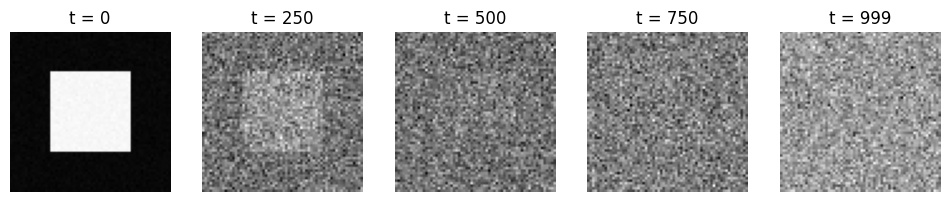

In [3]:
# Create a simple 64 × 64 image

x0 = torch.zeros(
    1, 1,
    image_size,
    image_size
)

x0[:, :, 16:48, 16:48] = 1.0


# Forward diffusion function

def add_noise(x0, t):

    noise = torch.randn_like(x0)

    a_bar = alpha_bar[t]

    xt = (
        torch.sqrt(a_bar) * x0
        + torch.sqrt(1 - a_bar) * noise
    )

    return xt


# Display different noise levels

timesteps = [0, 250, 500, 750, 999]

plt.figure(figsize=(12, 3))

for i, t in enumerate(timesteps):

    xt = add_noise(x0, t)

    plt.subplot(1, 5, i + 1)
    plt.imshow(xt[0, 0], cmap="gray")
    plt.title(f"t = {t}")
    plt.axis("off")

plt.show()

## Step 4: Reverse Denoising Loop

Start from Gaussian noise and iteratively move backward through the 1000 diffusion timesteps.

The reverse process progressively reduces the noise according to the diffusion schedule.

In [4]:
# Start from Gaussian noise

x = torch.randn(
    1, 1,
    image_size,
    image_size
)

# Store intermediate results

results = []

# Reverse denoising loop

for t in range(T - 1, -1, -1):

    # Reduce noise according to alpha

    x = x * torch.sqrt(alpha[t])

    # Add stochastic noise except at final step

    if t > 0:

        noise = torch.randn_like(x)

        x = x + torch.sqrt(beta[t]) * noise

    # Save selected stages

    if t in [750, 500, 250, 0]:

        results.append(x.clone())

print("Reverse denoising completed.")

Reverse denoising completed.


## Step 5: Visualize Reverse Denoising

Display the image arrays obtained at different stages of the reverse diffusion process.

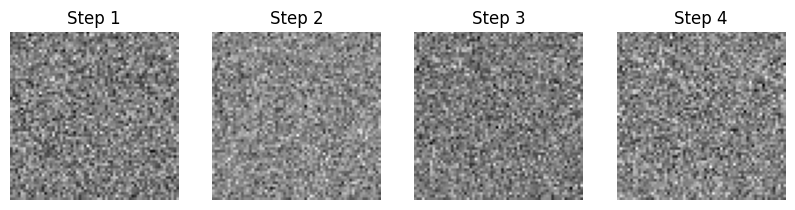

In [5]:
# Display reverse diffusion stages

plt.figure(figsize=(10, 3))

for i, image in enumerate(results):

    plt.subplot(
        1,
        len(results),
        i + 1
    )

    plt.imshow(
        image[0, 0],
        cmap="gray"
    )

    plt.title(f"Step {i + 1}")
    plt.axis("off")

plt.show()

## Step 6: Visualize the Noise Schedule

Display the linear variance schedule used during the diffusion process.

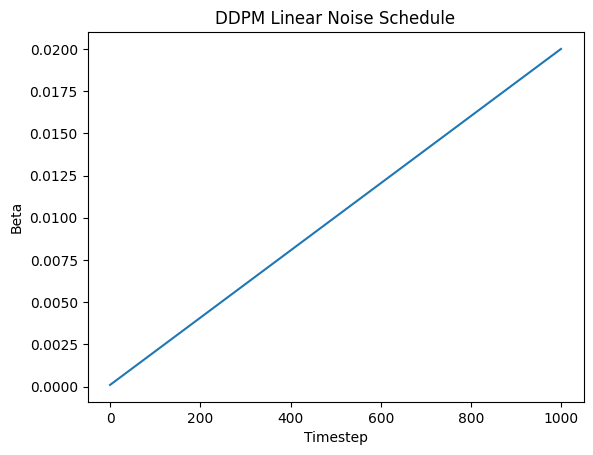

Initial beta: 9.999999747378752e-05
Final beta: 0.019999999552965164
Final alpha_bar: 4.035830352222547e-05


In [6]:
# Plot beta schedule

plt.plot(beta.numpy())

plt.xlabel("Timestep")
plt.ylabel("Beta")
plt.title("DDPM Linear Noise Schedule")

plt.show()

print("Initial beta:", beta[0].item())
print("Final beta:", beta[-1].item())
print("Final alpha_bar:", alpha_bar[-1].item())

## Conclusion

The DDPM forward and reverse diffusion processes were implemented using PyTorch, NumPy, and Matplotlib. A linear variance scheduler with 1000 timesteps and 64 × 64 image arrays was used. The forward process gradually adds Gaussian noise, while the reverse loop performs iterative denoising.